Brianna Lannerd- 09/19/2026- Lab 4- Two- Body Collisions
Disclaimer: Some of this code was copied from the code lesson module. AI was used to help with plot formatting as well as error checking and resolving

In [1]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt

Part A: 1d Collisions with Restitution

In [2]:
#Part A: Section 1- 1D collisional function
# Code below from code lesson module
def collide_1d(m1, m2, u1, u2, e=1.0):
    """1D collision with restitution e. e=1 elastic, e=0 perfectly inelastic."""
    total_m = m1 + m2
    # center-of-mass velocity is unchanged by the collision
    v_cm = (m1 * u1 + m2 * u2) / total_m
    v1 = v_cm - e * (m2 / total_m) * (u1 - u2)
    v2 = v_cm + e * (m1 / total_m) * (u1 - u2)
    return v1, v2

#Helper functions recommended in the assignment
def P_total(m1, m2, v1, v2): #momentum
    return m1 * v1 + m2 * v2


def ke_total(m1, m2, v1, v2): #total kinetic energy
    return 0.5 * m1 * v1**2 + 0.5 * m2 * v2**2

In [3]:
#Part A: Section 2- verifying of 3 limiting cases
cases = [
    ("Equal masses", 1.0, 1.0, 3.0, 0.0), #case 1
    ("Light ball into heavy ball", 0.1, 100.0, 3.0, 0.0), #case 2
    ("Heavy ball into light ball", 100.0, 0.1, 3.0, 0.0), #case 3
]

for label, m1, m2, u1, u2 in cases:
    v1, v2 = collide_1d(m1, m2, u1, u2, e=1.0) #call collision function
    print(f"{label}:")
    #Show changes in velocity before and after collision
    print(f"  before: u1 = {u1:.6f} m/s, u2 = {u2:.6f} m/s")
    print(f"  after : v1 = {v1:.6f} m/s, v2 = {v2:.6f} m/s")
    print()

Equal masses:
  before: u1 = 3.000000 m/s, u2 = 0.000000 m/s
  after : v1 = 0.000000 m/s, v2 = 3.000000 m/s

Light ball into heavy ball:
  before: u1 = 3.000000 m/s, u2 = 0.000000 m/s
  after : v1 = -2.994006 m/s, v2 = 0.005994 m/s

Heavy ball into light ball:
  before: u1 = 3.000000 m/s, u2 = 0.000000 m/s
  after : v1 = 2.994006 m/s, v2 = 5.994006 m/s



Part A: Section 3- Conservation Table

In [4]:
m1, m2 = 2.0, 3.0
u1, u2 = 4.0, 0.0

#To help show conservation of momentum and kinetic energy so will
#need to calculate/display before and after to find differences
p_before = P_total(m1, m2, u1, u2)
ke_before = ke_total(m1, m2, u1, u2)


#Run collision function for the different coefficients of restitution (aka dif collision types)
rows = []
for e in [1.0, 0.5, 0.0]:
    v1, v2 = collide_1d(m1, m2, u1, u2, e)
    p_after = P_total(m1, m2, v1, v2)
    ke_after = ke_total(m1, m2, v1, v2)
    rows.append((e, v1, v2, p_before, p_after, ke_before, ke_after))

#Print statements formatting so output can be copy and pasted into markdown
#cell that results in clean looking table
print("| e | v1 after (m/s) | v2 after (m/s) | p before | p after | KE before (J) | KE after (J) |")
print("|---:|---:|---:|---:|---:|---:|---:|")
for row in rows:
    e, v1, v2, pb, pa, keb, kea = row
    print(f"| {e:.1f} | {v1:.4f} | {v2:.4f} | {pb:.4f} | {pa:.4f} | {keb:.4f} | {kea:.4f} |")

| e | v1 after (m/s) | v2 after (m/s) | p before | p after | KE before (J) | KE after (J) |
|---:|---:|---:|---:|---:|---:|---:|
| 1.0 | -0.8000 | 3.2000 | 8.0000 | 8.0000 | 16.0000 | 16.0000 |
| 0.5 | 0.4000 | 2.4000 | 8.0000 | 8.0000 | 16.0000 | 8.8000 |
| 0.0 | 1.6000 | 1.6000 | 8.0000 | 8.0000 | 16.0000 | 6.4000 |


### Conservation Table

For a 2 kg block moving at 4 m/s striking a stationary 3 kg block:

| Restitution \(e\) | \(v_1\) after (m/s) | \(v_2\) after (m/s) | Momentum Before (kg·m/s) | Momentum After (kg·m/s) | KE Before (J) | KE After (J) |
|---|---:|---:|---:|---:|---:|---:|
| 1.0 | -0.8 | 3.2 | 8.0 | 8.0 | 16.0 | 16.0 |
| 0.5 | 0.4 | 2.4 | 8.0 | 8.0 | 16.0 | 8.8 |
| 0.0 | 1.6 | 1.6 | 8.0 | 8.0 | 16.0 | 6.4 |

Part A: Section 4- Momentum is conserved for all three values of e. When e=1, KE is conserved but when e is less than 1, kinetic energy decreases. The energy does not dissapear, as we know, energy must be conserved. It is logical to assume, the missing kinetic energy is converted into other forms of energy such as heat, sound, and deformation during the collision. Since this simulation does not measure those, it can give the appearance as if energy as a whole is not conserved. 

Part B- 2D Collisions in a Box

In [5]:
#Part B: Section 1- 2D collisional function
def collide_2d(m1, m2, r1, r2, v1, v2, e=1.0):
    """Resolve a 2D collision between two circles. Positions r, velocities v are 2-vectors."""
    r1, r2 = np.asarray(r1, float), np.asarray(r2, float)
    v1, v2 = np.asarray(v1, float), np.asarray(v2, float)

    n = r2 - r1
    dist = np.linalg.norm(n)
    if dist == 0:
        return v1, v2            # degenerate; skip
    n = n / dist                 # unit normal

    # normal components along n
    u1n, u2n = np.dot(v1, n), np.dot(v2, n)
    # tangential vector components 
    v1t = v1 - u1n * n
    v2t = v2 - u2n * n

    # 1D collision on the normal components
    new1n, new2n = collide_1d(m1, m2, u1n, u2n, e)

    return v1t + new1n * n, v2t + new2n * n

def overlapping(r1, r2, radius1, radius2):
    return np.linalg.norm(np.asarray(r2) - np.asarray(r1)) < (radius1 + radius2)




#Part B: Section 2- Adding Wall bouncing
def wall_bouncing(body, W, H):
    """Reflect velocity and clamp a circular body back inside the box."""
    x, y = body["r"]
    vx, vy = body["v"]
    R = body["radius"]

    if x - R < 0:
        x = R
        vx = abs(vx)
    elif x + R > W:
        x = W - R
        vx = -abs(vx)

    if y - R < 0:
        y = R
        vy = abs(vy)
    elif y + R > H:
        y = H - R
        vy = -abs(vy)

    body["r"] = np.array([x, y], dtype=float)
    body["v"] = np.array([vx, vy], dtype=float)


def total_momentum(bodies):
    return sum(b['m'] * b['v'] for b in bodies)   # vector sum


def total_ke(bodies):
    return sum(0.5 * b['m'] * np.dot(b['v'], b['v']) for b in bodies)


def center_of_mass(bodies):
    total_mass = sum(body["m"] for body in bodies)
    return sum((body["m"] * body["r"] for body in bodies),
               start=np.zeros(2)) / total_mass


def copy_bodies(bodies):
    """Make an independent copy of the list-of-bodies state."""
    return [
        {
            "m": body["m"],
            "r": np.array(body["r"], dtype=float).copy(),
            "v": np.array(body["v"], dtype=float).copy(),
            "radius": body["radius"],
        }
        for body in bodies
    ]

#Part B: Section 3 - Main Loop
def simulate_two_bodies(initial_bodies, dt, steps, e=1.0,
                        W=None, H=None, use_walls=True):
    """Advance two bodies with no continuous forces and resolve collisions."""
    bodies = copy_bodies(initial_bodies)

    times = np.arange(steps + 1) * dt
    r1_hist = [bodies[0]["r"].copy()]
    r2_hist = [bodies[1]["r"].copy()]
    p_hist = [total_momentum(bodies)]
    ke_hist = [total_ke(bodies)]
    com_hist = [center_of_mass(bodies)]

    collision_steps = []

    for step in range(1, steps + 1):
        # Euler-Cromer:
        # No continuous force in this lab, so velocity is unchanged
        # until an instantaneous collision impulse occurs.
        for body in bodies:
            body["r"] = body["r"] + body["v"] * dt

        if use_walls:
            for body in bodies:
                wall_bouncing(body, W, H)

        r1 = bodies[0]["r"]
        r2 = bodies[1]["r"]

        v1 = bodies[0]["v"]
        v2 = bodies[1]["v"]

        R1 = bodies[0]["radius"]
        R2 = bodies[1]["radius"]

        m1 = bodies[0]["m"]
        m2 = bodies[1]["m"]

        # Only resolve if the bodies are moving toward each other
        approaching = np.dot(v2 - v1, r2 - r1) < 0

        if overlapping(r1, r2, R1, R2) and approaching:
            v1, v2 = collide_2d(
                m1, m2,
                r1, r2,
                v1, v2,
                e
            )

            bodies[0]["v"] = v1
            bodies[1]["v"] = v2

            collision_steps.append(step)

        r1_hist.append(bodies[0]["r"].copy())
        r2_hist.append(bodies[1]["r"].copy())
        p_hist.append(total_momentum(bodies))
        ke_hist.append(total_ke(bodies))
        com_hist.append(center_of_mass(bodies))

    return {
        "time": times,
        "r1": np.array(r1_hist),
        "r2": np.array(r2_hist),
        "p": np.array(p_hist),
        "ke": np.array(ke_hist),
        "com": np.array(com_hist),
        "collision_steps": collision_steps,
        "final_bodies": bodies,
    }

In [6]:
#Part B: Section 4 - Running the simulation
W, H = 10.0, 6.0
dt = 0.01
steps = 1200

initial_bodies_B = [
    {
        "m": 2.0,
        "r": np.array([2.0, 2.0]),
        "v": np.array([2.2, 0.8]),
        "radius": 0.35,
    },
    {
        "m": 3.0,
        "r": np.array([7.0, 4.0]),
        "v": np.array([-1.5, -0.5]),
        "radius": 0.50,
    },
]

result_B = simulate_two_bodies(
    initial_bodies_B, dt=dt, steps=steps, e=1.0,
    W=W, H=H, use_walls=True
)

print("Number of ball-ball collisions detected:", len(result_B["collision_steps"]))
print("First few collision steps:", result_B["collision_steps"][:10])

Number of ball-ball collisions detected: 1
First few collision steps: [117]


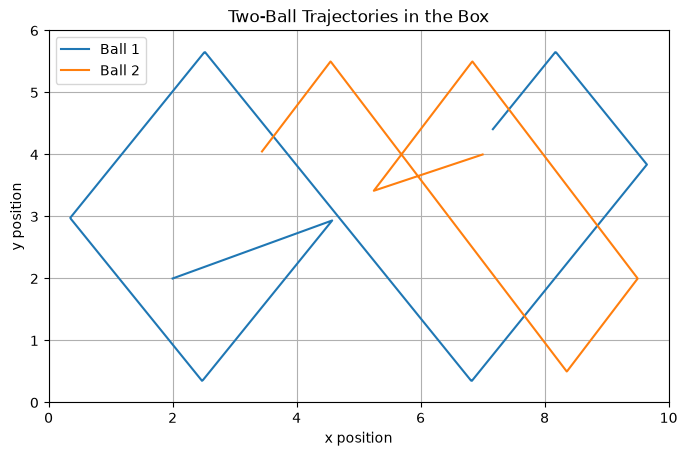

In [7]:

# Part B: Section 4 -  Plotting it
plt.figure(figsize=(8, 7))

plt.plot(result_B["r1"][:, 0], result_B["r1"][:, 1], label="Ball 1")
plt.plot(result_B["r2"][:, 0], result_B["r2"][:, 1], label="Ball 2")

plt.xlim(0, W)
plt.ylim(0, H)

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Two-Ball Trajectories in the Box")

plt.gca().set_aspect("equal", adjustable="box")

plt.legend()
plt.grid(True)
plt.show()

This graph shows the trajectories of two balls in a box. The x axis shows the x position and the y-axis shows the y position. The sharp corners show the changes in directions as the balls either bounce against the wall or collide with eachother.

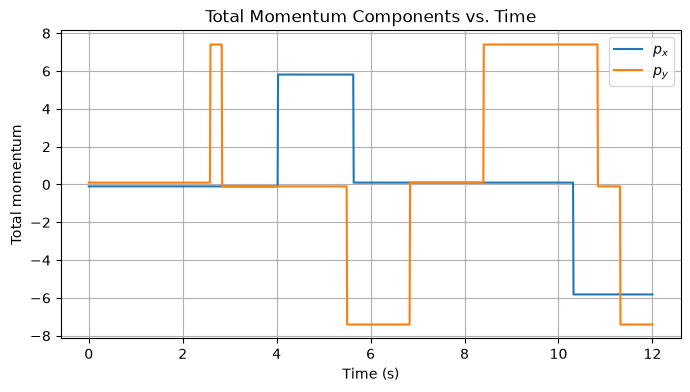

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(result_B["time"], result_B["p"][:, 0], label="$p_x$")
plt.plot(result_B["time"], result_B["p"][:, 1], label="$p_y$")
plt.xlabel("Time (s)")
plt.ylabel("Total momentum")
plt.title("Total Momentum Components vs. Time")
plt.legend()
plt.grid(True)
plt.show()

This graph shows that total momentum for each component stays constant in between wall collisions. When the ball collides with the wall, the momentum changes because the wall exerts an internal impulse on the ball that is not calculated for this simulation which results in momentum being "added" to the system. Is the walls were accounted for in the system then momentum would be conserved.

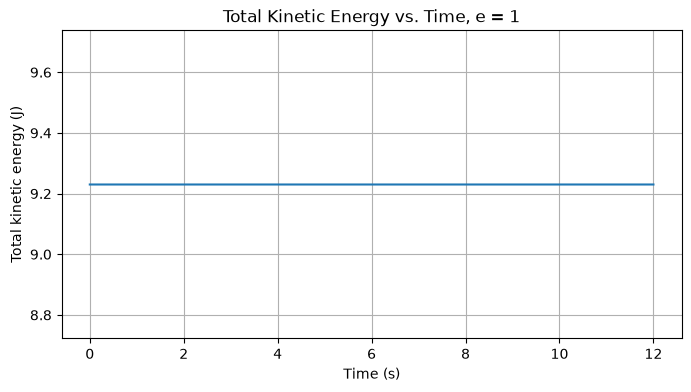

Initial KE: 9.23
Final KE:   9.229999999999997
Maximum absolute KE change: 3.552713678800501e-15


In [9]:
plt.figure(figsize=(8, 4))
plt.plot(result_B["time"], result_B["ke"])
plt.xlabel("Time (s)")
plt.ylabel("Total kinetic energy (J)")
plt.title("Total Kinetic Energy vs. Time, e = 1")
plt.grid(True)
plt.show()

print("Initial KE:", result_B["ke"][0])
print("Final KE:  ", result_B["ke"][-1])
print("Maximum absolute KE change:",
      np.max(np.abs(result_B["ke"] - result_B["ke"][0])))

The graph above shows that total kinetic is conserved the entire time for an elastic collision which is what would be physically expected from an elastic collision by definition. 
Part B- Section 5:
With elastic collisions and elastic walls, the KE should remain constant over time. As explained above, the line on the graph is completely horizontal which means the simulation accurately shows that KE doesn't change over time in the elastic collisions. The total momentum of the balls doesn't remain constant when they bounch off the walls because the walls actually exert an impulse which acts as an external force acting on the system. This means the momentum of the balls change since the walls were not considered/ factored into the system in this simulation.

Part C- Inelastic Collisions and Energy Accounting

In [10]:
#Part C: Section 1- Parameterized your 2D simulation by e
initial_bodies_C = [
    {
        "m": 2.0,
        "r": np.array([2.0, 3.0]),
        "v": np.array([2.0, 0.0]),
        "radius": 0.40,
    },
    {
        "m": 3.0,
        "r": np.array([6.0, 3.0]),
        "v": np.array([-1.0, 0.0]),
        "radius": 0.50,
    },
]

# Part C: Section 2: Run a sweep
e_values = [1.0, 0.9, 0.7, 0.5]

results_C = {}

for e in e_values:
    results_C[e] = simulate_two_bodies(
        initial_bodies_C,
        dt=0.002,
        steps=2500,
        e=e,
        W=12.0,
        H=6.0,
        use_walls=True,
    )

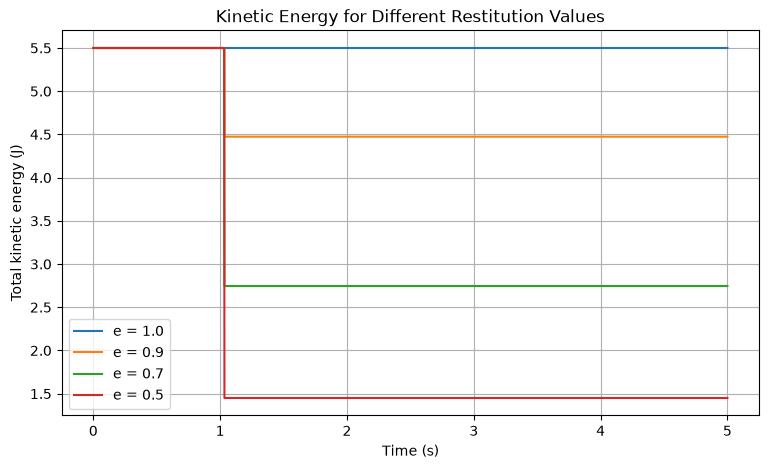

In [11]:
#Part C- Section 3: Quantify the loss
#Plot total KE vs time
plt.figure(figsize=(9, 5))

for e in e_values:
    result = results_C[e]
    plt.plot(result["time"], result["ke"], label=f"e = {e}")

plt.xlabel("Time (s)")
plt.ylabel("Total kinetic energy (J)")
plt.title("Kinetic Energy for Different Restitution Values")
plt.legend()
plt.grid(True)
plt.show()

The kinetic energy is constant until the balls collide because no external forces are acting on them. When the collision occurs, KE decreases unless the value of the coefficient of restitution is 1 because that means its an elastic collision and by definition KE doens't decrease. As shown on the graph, as the coefficient of restitution decreases, a larger fraction of kinetic energy is "lost".

In [12]:
#Part C: Section 3- Quantifying the Loss
def theoretical_ke_loss_fraction(m1, m2, u1, u2, e):
    mu = (m1 * m2) / (m1 + m2)
    delta_ke = 0.5 * mu * (1 - e**2) * (u1 - u2)**2
    ke_before = 0.5 * m1 * u1**2 + 0.5 * m2 * u2**2
    return delta_ke / ke_before


m1 = initial_bodies_C[0]["m"]
m2 = initial_bodies_C[1]["m"]
u1 = initial_bodies_C[0]["v"][0]
u2 = initial_bodies_C[1]["v"][0]

comparison_rows = []

for e in e_values:
    result = results_C[e]
    first_step = result["collision_steps"][0]

    # Because the collision is resolved during this step:
    ke_before_collision = result["ke"][first_step - 1]
    ke_after_collision = result["ke"][first_step]

    measured_fraction = (
        ke_before_collision - ke_after_collision
    ) / ke_before_collision

    theoretical_fraction = theoretical_ke_loss_fraction(
        m1, m2, u1, u2, e
    )

    comparison_rows.append(
        (e, measured_fraction, theoretical_fraction,
         measured_fraction - theoretical_fraction)
    )

#Print statements formatting so output can be copy and pasted into markdown
#cell that results in clean looking table
print("| e | Measured KE-loss fraction | Theory | Difference |")
print("|---:|---:|---:|---:|")
for e, measured, theory, difference in comparison_rows:
    print(f"| {e:.1f} | {measured:.6f} | {theory:.6f} | {difference:.2e} |")

| e | Measured KE-loss fraction | Theory | Difference |
|---:|---:|---:|---:|
| 1.0 | 0.000000 | 0.000000 | 0.00e+00 |
| 0.9 | 0.186545 | 0.186545 | 5.55e-17 |
| 0.7 | 0.500727 | 0.500727 | 1.11e-16 |
| 0.5 | 0.736364 | 0.736364 | 0.00e+00 |


| e | Measured KE-loss fraction | Theory | Difference |
|---:|---:|---:|---:|
| 1.0 | 0.000000 | 0.000000 | 0.00e+00 |
| 0.9 | 0.186545 | 0.186545 | 5.55e-17 |
| 0.7 | 0.500727 | 0.500727 | 1.11e-16 |
| 0.5 | 0.736364 | 0.736364 | 0.00e+00 |

The difference between the measured kinetic energy and the theoreticla kinetic energy is very small if not neglible for the simulation. This shows that the measured behavior matched was is physically expected by theory and justifies the success of the simulation for head on collisions.

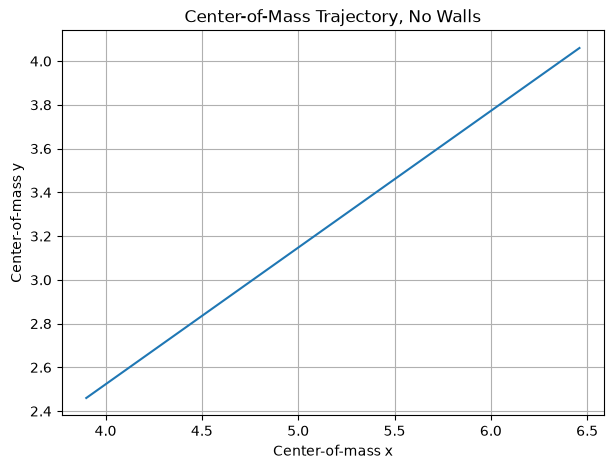

Mean COM velocity: [0.32 0.2 ]
Maximum deviation from mean COM velocity: 4.973588446654091e-13


In [13]:
#Part C: Section 4- The center of mass test
initial_bodies_com = [
#Body 1
    {
        "m": 2.0,
        "r": np.array([1.5, 1.5]),
        "v": np.array([2.0, 0.8]),
        "radius": 0.35,
    },
#Body 2
    {
        "m": 3.0,
        "r": np.array([5.5, 3.1]),
        "v": np.array([-0.8, -0.2]),
        "radius": 0.50,
    },
]

result_com = simulate_two_bodies(
    initial_bodies_com,
    dt=0.005,
    steps=1600,
    e=1.0,
    use_walls=False
)

plt.figure(figsize=(7, 5))
plt.plot(result_com["com"][:, 0], result_com["com"][:, 1])
plt.xlabel("Center-of-mass x")
plt.ylabel("Center-of-mass y")
plt.title("Center-of-Mass Trajectory, No Walls")
plt.grid(True)
plt.show()

# Check that COM velocity is nearly constant.
com_velocity = np.diff(result_com["com"], axis=0) / 0.005
print("Mean COM velocity:", np.mean(com_velocity, axis=0))
print("Maximum deviation from mean COM velocity:",
      np.max(np.linalg.norm(
          com_velocity - np.mean(com_velocity, axis=0),
          axis=1
      )))

The graph shows the relationship between the center of mass y and x position is linear. This means when there aren't walls or other external forces, the center of mass velocity is constant (as determined by if you were to take the derivative of the equation for this graph it would be a horizontal line at the value of the slope of this line).

This is a powerful correctness test because the center of mass should not be affecteed by internal conditions. The individual speeds of the balls can change but the total momentum of the system should not. The forces they extert on eachother when they collide should follow newtons laws and be equal in oppositite. The fact the graph shows a straight line helps validate that the system is doing the simulation correctly. 

Part C: Section 5 -Final Summary/ Analysis
For any scenario where e is less than 1, the total KE should never increase during a collision. When the balls are moving around (but not colliding), it is expected that ke will stay constant until they collide, but it should always decrease when a collision occurs if e is less than 1 (aka it is an inelastic collision). If the KE every increased, it means the calculations are wrong and somehow you are adding energy to the system in the form of kinetic energy which means the code is violating conservation laws. Saying KE never increases can be considered useful as a correctness test because that fact is true for all physical behavior of the balls in this scenario so it doesn't matter where the balls are in the box or where/when they collide because whether they are moving freely or colliding, KE should never increase. 

Bonus Challenge- Gas in a Box

In [14]:
# Bonus Challenge - Gas in a Box
#Editing the wall bouncing function to return the impulse on the wall, so that momentum is conserved.
#Bonus part 1
def wall_bouncing(body, W, H):
    x, y = body["r"]
    vx, vy = body["v"]
    R = body["radius"]
    m = body["m"]

    wall_impulse = np.array([0.0, 0.0])

    if x - R < 0:
        old_vx = vx
        x = R
        vx = abs(vx)
        wall_impulse[0] += -m * (vx - old_vx)

    elif x + R > W:
        old_vx = vx
        x = W - R
        vx = -abs(vx)
        wall_impulse[0] += -m * (vx - old_vx)

    if y - R < 0:
        old_vy = vy
        y = R
        vy = abs(vy)
        wall_impulse[1] += -m * (vy - old_vy)

    elif y + R > H:
        old_vy = vy
        y = H - R
        vy = -abs(vy)
        wall_impulse[1] += -m * (vy - old_vy)

    body["r"] = np.array([x, y])
    body["v"] = np.array([vx, vy])

    return wall_impulse
N = 50
W = 10.0
H = 10.0

#Bonus- part 2
mass = 1.0
radius = 0.15
speed = 5

dt = 0.005
steps = 5000

rng = np.random.default_rng(42)

bodies = []

for i in range(N):

    # Random starting position inside the box
    position = np.array([
        rng.uniform(radius, W - radius),
        rng.uniform(radius, H - radius)
    ])

    # Random direction
    theta = rng.uniform(0, 2*np.pi)

    velocity = speed * np.array([
        np.cos(theta),
        np.sin(theta)
    ])

    bodies.append({
        "m": mass,
        "r": position,
        "v": velocity,
        "radius": radius
    })

In [15]:
ke_history = []
p_history = []

# Momentum transferred to the walls
wall_momentum = np.array([0.0, 0.0])

for step in range(steps):

    # Move every ball
    for body in bodies:
        body["r"] = body["r"] + body["v"] * dt

    # Check wall collisions
    for body in bodies:
        wall_momentum += wall_bouncing(body, W, H)

    # Check every unique pair of balls
    for i in range(N):
        for j in range(i + 1, N):

            r1 = bodies[i]["r"]
            r2 = bodies[j]["r"]

            v1 = bodies[i]["v"]
            v2 = bodies[j]["v"]

            R1 = bodies[i]["radius"]
            R2 = bodies[j]["radius"]

            m1 = bodies[i]["m"]
            m2 = bodies[j]["m"]

            approaching = np.dot(v2 - v1, r2 - r1) < 0

            if overlapping(r1, r2, R1, R2) and approaching:

                v1, v2 = collide_2d(
                    m1, m2,
                    r1, r2,
                    v1, v2,
                    e=1.0
                )

                bodies[i]["v"] = v1
                bodies[j]["v"] = v2

    # Store total kinetic energy
    ke_history.append(total_ke(bodies))

    # Momentum of the balls
    p_balls = total_momentum(bodies)

    # Total system momentum = balls + walls
    p_total = p_balls + wall_momentum

    p_history.append(p_total.copy())

p_history = np.array(p_history)
ke_history = np.array(ke_history)

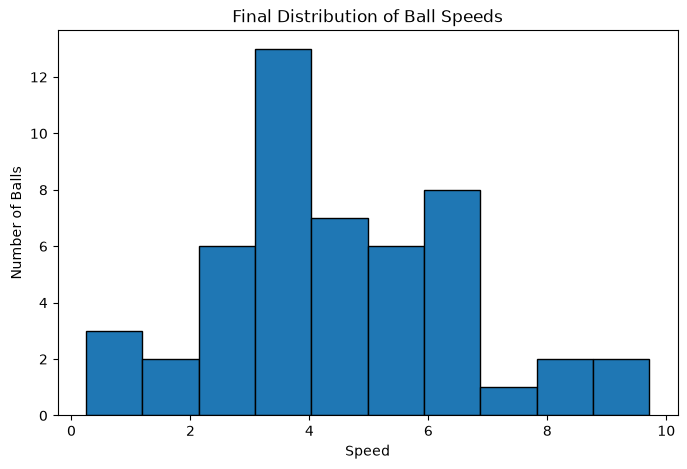

In [16]:
#Bonus - Part 3
final_speeds = [
    np.linalg.norm(body["v"])
    for body in bodies
]

plt.figure(figsize=(8, 5))

plt.hist(final_speeds, bins=10, edgecolor="black")

plt.xlabel("Speed")
plt.ylabel("Number of Balls")
plt.title("Final Distribution of Ball Speeds")

plt.show()

For this graph, the balls all began with the same speed (5.0), but collisions (elastic ones) cause the Kinetic energy/ speed of individual particles to change. As these repeated collisions happen, more and more energy is redistributed which leads to a distribution of different speeds of particles. The distribution is not smooth or a perfect Maxwell-Boltzmann distribution due to the small sample of balls simulated. If you were to increase the number of balls, the distribution would start looking more and more like a Maxwell-Boltzmann distribution.

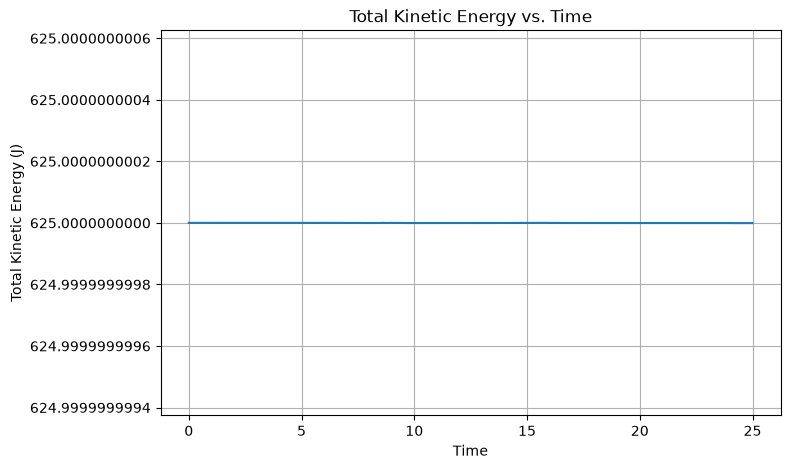

In [17]:
#Bonus- Part 4
time = np.arange(steps) * dt

plt.figure(figsize=(8, 5))

plt.plot(time, ke_history)

plt.xlabel("Time")
plt.ylabel("Total Kinetic Energy (J)")
plt.title("Total Kinetic Energy vs. Time")

plt.ticklabel_format(style="plain", axis="y", useOffset=False)

plt.grid(True)
plt.show()

The graph above shows total kinetic energy is conserved over time throughout the simulation (the graph is a horizontal line).

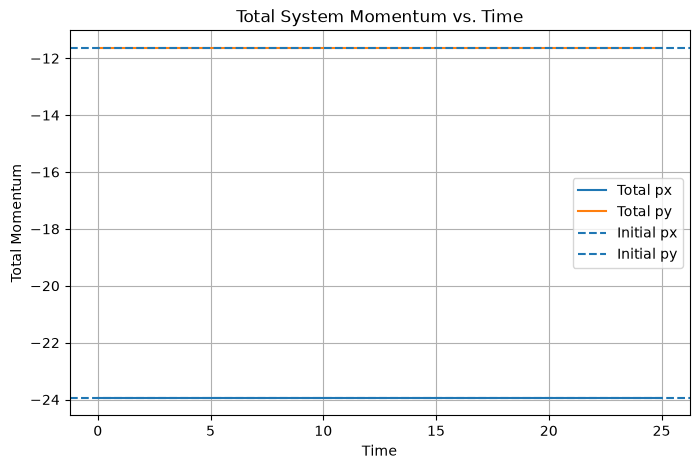

In [18]:
time = np.arange(steps) * dt

plt.figure(figsize=(8, 5))

plt.plot(time, p_history[:, 0], label="Total px")
plt.plot(time, p_history[:, 1], label="Total py")

plt.axhline(
    p_history[0, 0],
    linestyle="--",
    label="Initial px"
)

plt.axhline(
    p_history[0, 1],
    linestyle="--",
    label="Initial py"
)

plt.xlabel("Time")
plt.ylabel("Total Momentum")
plt.title("Total System Momentum vs. Time")

plt.legend()
plt.grid(True)

plt.show()

The total x and y components of momentum remain constant throughout the simulation (over time). This is shown by the initial and final momentum values in both directions overlapping which shows momentum is conserved.

Bonus- Part 5
Even though every ball starts with the same speed, the collisions between balls actually causes the kinetic energy to be redistributed among balls. Because of the randomness of these collisions, the redistribution is not uniform and some balls gain speed and some balls lose speed. This results in the balls when looked at as a system having a distribution of various speeds instead of each ball having the same speed it started with. This tells us that temperature can be related to the overall distribution of the speed/ kinetic energy of the system rather than directly related to the speed of each individual particle. For the statistical mechanics aspect, it shows the the behavior of the system can be described using these such distributions and averages, even though each individual particles motion is always changing.